# Zero Shot Семантическая Сегментация

In [10]:
from PIL import Image
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

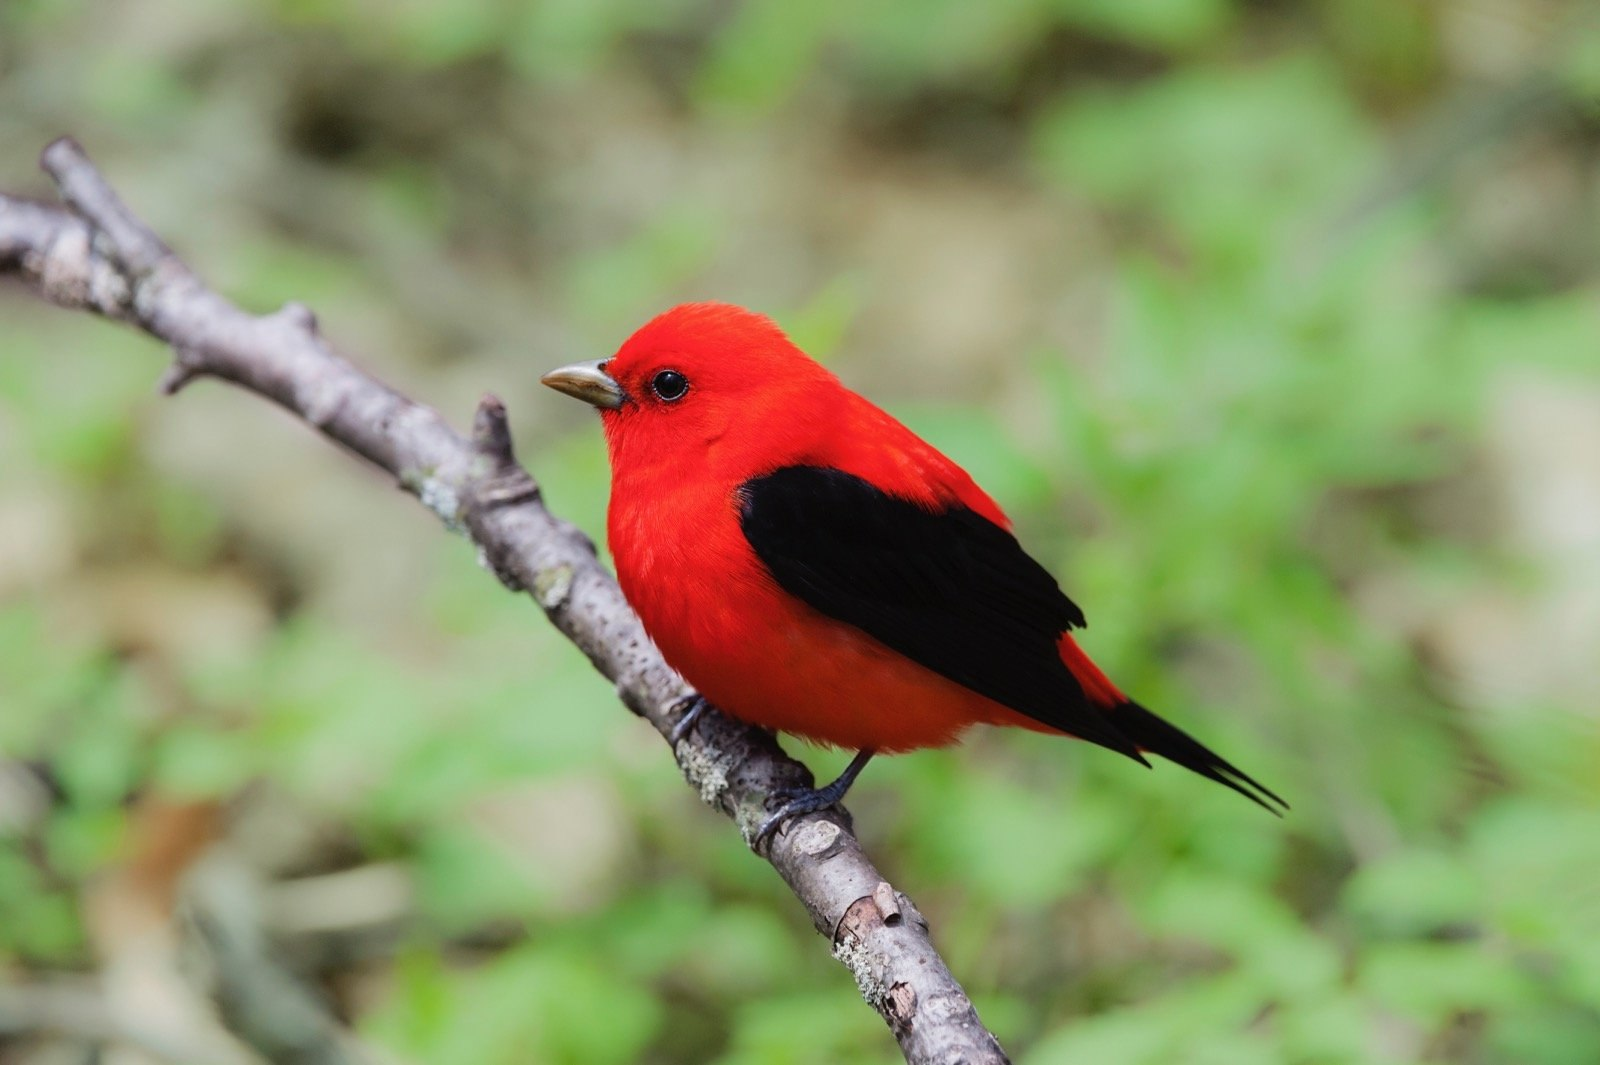

In [11]:
image = Image.open("images/4.jpg")
image

In [18]:
prompts = ["a bird", "wood", "a wing"]

inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt")

Unused or unrecognized kwargs: padding.


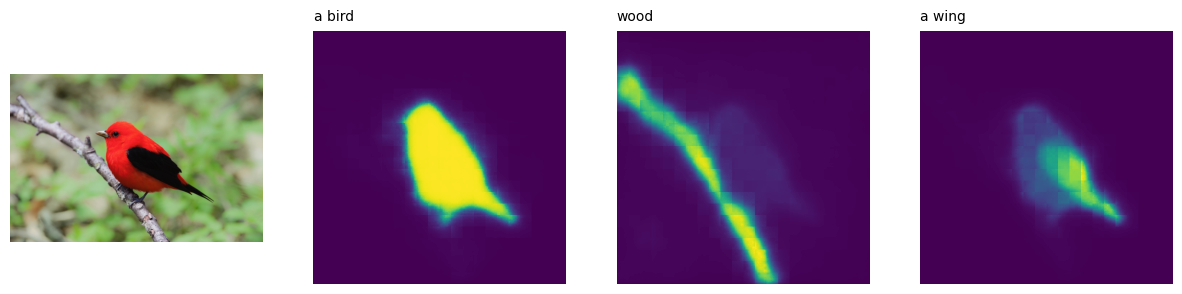

In [19]:
import torch
import matplotlib.pyplot as plt

# predict
with torch.no_grad():
  outputs = model(**inputs)

preds = outputs.logits.unsqueeze(1)

# visualize prediction
_, ax = plt.subplots(1, 4, figsize=(15, 4))
[a.axis('off') for a in ax.flatten()]
ax[0].imshow(image)
[ax[i+1].imshow(torch.sigmoid(preds[i][0])) for i in range(3)];
[ax[i+1].text(0, -15, prompts[i]) for i in range(3)];

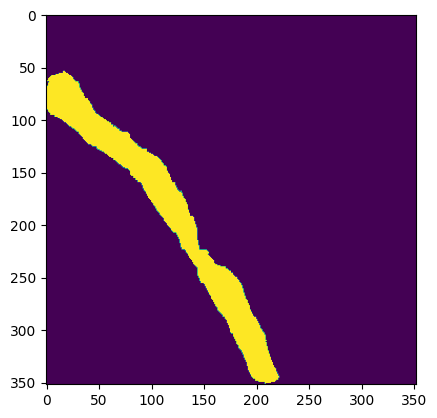

In [34]:
import cv2 

i = 1 # class
gray_image = torch.sigmoid(preds[i][0]).numpy() * 255

(thresh, bw_image) = cv2.threshold(gray_image, 100, 255, cv2.THRESH_BINARY)

# fix color format
cv2.cvtColor(bw_image, cv2.COLOR_BGR2RGB)

plt.imshow(bw_image);